# 06 · Visualizations

Genera figuras finales desde los artefactos de integración.

Este notebook:

- no entrena modelos;
- no recalcula features;
- no recalcula clustering;
- no recalcula predicciones supervisadas;
- solo consume artefactos generados por `05_supervised_unsupervised_integration.ipynb`.

Entradas principales:

- `artifacts/integration/integrated_results.csv`
- `artifacts/integration/cluster_tag_matrix.csv`
- `artifacts/integration/cluster_topic_matrix.csv`
- `artifacts/integration/cluster_source_matrix.csv`
- `artifacts/integration/top_tags_by_cluster.csv`
- `artifacts/integration/vallejo_view.csv`

Salidas:

- `figs/poemas_2d_integracion.png`
- `figs/top_tags_by_cluster.png`
- `figs/cluster_source_matrix.png`
- `figs/cluster_topic_matrix.png`
- `figs/vallejo_projection.png`

In [1]:
# %%
from __future__ import annotations

import sys
from pathlib import Path

# Permite importar modules/ y utils/ cuando el notebook se ejecuta desde notebook/
sys.path.insert(0, "..")

%load_ext autoreload
%autoreload 2

# python
import json

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# modules
from modules.integration import parse_json_list
from modules.io import (
    artifact_path,
    fig_path,
    load_csv,
    ensure_dir,
    display_path,
)

# typings
from pandas import DataFrame as PandasDF

# setup
plt.style.use('seaborn-v0_8')
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("max_colwidth", None)

plt.rcParams["figure.figsize"] = (8, 6)

## 1. Cargar artefactos de integración

In [2]:
integration_path = artifact_path("integration", "integrated_results.csv")

integrated: PandasDF = load_csv(integration_path)

list_like_cols = [
    "original_tags",
    "predicted_tags",
    "nearest_titles_cosine",
    "nearest_scores_cosine",
]

for col in list_like_cols:
    if col in integrated.columns:
        integrated[col] = integrated[col].apply(parse_json_list)

ensure_dir(fig_path())

display(integrated.head(3))
print(integrated.shape)

,poem_id,title,title_raw,poet,poet_raw,source,corpus_role,poem,poem_raw,poem_processed,original_tags,cluster_km,cluster_gmm,cluster_agg,cluster_dbscan,lda_topic_id,lda_topic_prob,lda_topic_terms,nearest_titles_cosine_json,nearest_scores_cosine_json,embedding_x,embedding_y,nearest_titles_cosine,nearest_scores_cosine,predicted_tags,predicted_tags_json
0,poetry_foundation::000000::d1e86366cdbb,objects used to prop open a window,\r\r\n Objects Used to Prop Open a Window\r\r\n,michelle menting,Michelle Menting,poetry_foundation,reference,dog bone stapler cribbage board garlic press because this window is looselacks suction lacks grip bungee cord bootstrap dog leash leather belt because this window had sash cords they frayed they broke feather duster thatch of straw empty bottle of elmers glue because this window is loudits hinges clack open clack shut stuffed bear baby blanket single crib newel because this window is split its dividing in two velvet moss sagebrush willow branch robins wing because this window its paneless its only a frame of air,"\r\r\nDog bone, stapler,\r\r\ncribbage board, garlic press\r\r\n because this window is loose—lacks\r\r\nsuction, lacks grip.\r\r\nBungee cord, bootstrap,\r\r\ndog leash, leather belt\r\r\n because this window had sash cords.\r\r\nThey frayed. They broke.\r\r\nFeather duster, thatch of straw, empty\r\r\nbottle of Elmer's glue\r\r\n because this window is loud—its hinges clack\r\r\nopen, clack shut.\r\r\nStuffed bear, baby blanket,\r\r\nsingle crib newel\r\r\n because this window is split. It's dividing\r\r\nin two.\r\r\nVelvet moss, sagebrush,\r\r\nwillow branch, robin's wing\r\r\n because this window, it's pane-less. It's only\r\r\na frame of air.\r\r\n",dog bone stapler cribbag board garlic press window looselack suction lack grip bunge cord bootstrap dog leash leather belt window sash cord fray break feather duster thatch straw bottl elmer glue window loudit he clack open clack shut stuf bear babi blanket singl crib newel window split divid velvet moss sagebrush willow branch robin wing window paneless frame air,[],0.0,1.0,0.0,-1.0,1.0,0.6896,"like, tree, white, water, blue","[""confession of a bird watcher"", ""mother and child body and soul"", ""supple cord"", ""schizotableau"", ""winter""]","[0.1981, 0.1817, 0.1762, 0.1747, 0.173]",-25.025835,-55.625130,"[confession of a bird watcher, mother and child body and soul, supple cord, schizotableau, winter]","[0.1981, 0.1817, 0.1762, 0.1747, 0.173]",[],[]
1,poetry_foundation::000001::0dbfeaec7a94,the new church,\r\r\n The New Church\r\r\n,lucia cherciu,Lucia Cherciu,poetry_foundation,reference,the old cupola glinted above the clouds shone among fir trees but it took him an hour for the half mile all the way up the hill as he trailed the village passed him by greeted him asked about his health but everybody hurried to catch the mass left him leaning against fences measuring the road with the walking stick he sculpted he yearned for the day when the new church would be builtright across the road now it rises above the moon saints in frescoes meet the eye and only the rain has started to cut through the shingles on the roof of his empty house the apple trees have taken over the sky sequestered the gate sidled over the porch,"\r\r\nThe old cupola glinted above the clouds, shone\r\r\namong fir trees, but it took him an hour\r\r\nfor the half mile all the way up the hill. As he trailed,\r\r\nthe village passed him by, greeted him,\r\r\nasked about his health, but everybody hurried\r\r\nto catch the mass, left him leaning against fences,\r\r\nmeasuring the road with the walking stick he sculpted.\r\r\nHe yearned for the day when the new church\r\r\nwould be built—right across the road. Now\r\r\nit rises above the moon: saints in frescoes\r\r\nmeet the eye, and only the rain has started to cut\r\r\nthrough the shingles on the roof of his empty\r\r\nhouse. The apple trees have taken over the sky,\r\r\nsequestered the gate, sidled over the porch.\r\

(13858, 26)


In [3]:
required_columns = {
    "poem_id",
    "title",
    "poet",
    "source",
    "corpus_role",
    "cluster_km",
    "embedding_x",
    "embedding_y",
}

missing_columns = required_columns.difference(integrated.columns)

if missing_columns:
    raise ValueError(
        f"Faltan columnas requeridas en integrated_results.csv: {missing_columns}"
    )

if integrated["poem_id"].duplicated().any():
    raise ValueError("integrated_results.csv tiene poem_id duplicados.")

print("Integrated results validado correctamente.")

Integrated results validado correctamente.


## 2. Proyección 2D integrada

Visualiza la proyección 2D generada en el notebook 04, coloreada por `cluster_km`.

Se resaltan poemas asociados a Vallejo usando `poet`, `poet_raw`, `source` o títulos relacionados.

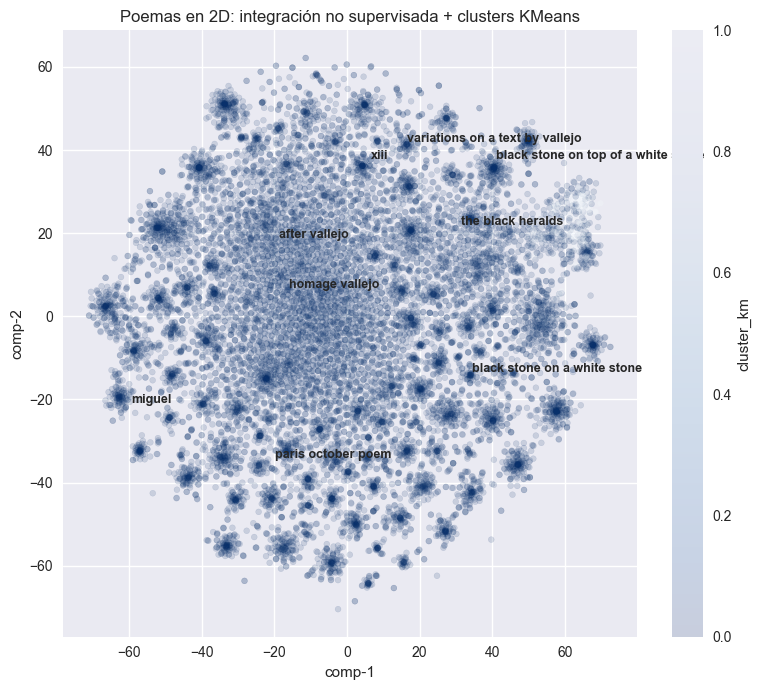

Figura guardada en: /VersoVector/figs/poemas_2d_integracion.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 7))

sc = ax.scatter(
    integrated["embedding_x"],
    integrated["embedding_y"],
    c=integrated["cluster_km"],
    s=18,
    alpha=0.15,
    cmap="Blues_r",
)

ax.set_title("Poemas en 2D: integración no supervisada + clusters KMeans")
ax.set_xlabel("comp-1")
ax.set_ylabel("comp-2")

plt.colorbar(sc, ax=ax, label="cluster_km")

poet_series = integrated.get(
    "poet",
    pd.Series(index=integrated.index, dtype=str),
).astype(str)

poet_raw_series = integrated.get(
    "poet_raw",
    pd.Series(index=integrated.index, dtype=str),
).astype(str)

source_series = integrated.get(
    "source",
    pd.Series(index=integrated.index, dtype=str),
).astype(str)

title_series = integrated.get(
    "title",
    pd.Series(index=integrated.index, dtype=str),
).astype(str)

mask_vallejo = (
    poet_series.str.contains("vallejo", case=False, na=False)
    | poet_raw_series.str.contains("vallejo", case=False, na=False)
    | source_series.eq("cesar_vallejo")
    | title_series.str.contains("black herald|vallejo", case=False, na=False)
)

for _, row in integrated.loc[mask_vallejo].iterrows():
    ax.annotate(
        row["title"],
        xy=(row["embedding_x"], row["embedding_y"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        weight="bold",
    )

plt.tight_layout()

out = fig_path("poemas_2d_integracion.png")
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {display_path(out)}")

## 3. Vista focal de Vallejo

In [6]:
vallejo_path = artifact_path("integration", "vallejo_view.csv")

if vallejo_path.is_file():
    vallejo_view: PandasDF = load_csv(vallejo_path)

    for col in list_like_cols:
        if col in vallejo_view.columns:
            vallejo_view[col] = vallejo_view[col].apply(parse_json_list)

    display(vallejo_view)
else:
    vallejo_view = integrated.loc[mask_vallejo].copy()
    display(vallejo_view)

,title,title_raw,poet,poet_raw,source,corpus_role,cluster_km,cluster_gmm,cluster_agg,cluster_dbscan,lda_topic_id,lda_topic_prob,lda_topic_terms,predicted_tags,nearest_titles_cosine,nearest_scores_cosine,embedding_x,embedding_y
0,homage vallejo,\r\r\n Homage: Vallejo\r\r\n,ishion hutchinson,Ishion Hutchinson,poetry_foundation,reference,0.0,1.0,0.0,102.0,1.0,0.7407,"like, tree, white, water, blue",[social commentaries],"[thirteen ways of looking at a blackbird, black stone on a white stone, ghazal after ferguson, black stone on top of a white stone, sloweddown blackbird]","[0.3723, 0.3086, 0.2982, 0.2948, 0.2852]",-17.932055,5.242527
1,after vallejo,\r\r\n After Vallejo\r\r\n,tom sleigh,Tom Sleigh,poetry_foundation,reference,0.0,1.0,0.0,-1.0,5.0,0.4070,"like, light, bodi, hand, eye",[living],"[east of carthage an idyll, being serious, how long, the ballad of reading gaol, song of myself version]","[0.2323, 0.232, 0.2276, 0.2242, 0.2241]",-20.786057,17.201680
2,variations on a text by vallejo,\r\r\n Variations on a Text by Vallejo\r\r\n,donald justice,Donald Justice,poetry_foundation,reference,0.0,0.0,0.0,-1.0,1.0,0.4737,"like, tree, white, water, blue","[living, relationships]","[a poem called day, animalistic hymn, forecast, a blessing for wedding, kef]","[0.2571, 0.249, 0.2441, 0.2217, 0.216]",14.576059,40.260690
3,black stone on a white stone,\r\r\n Black Stone on a White Stone\r\r\n,cesar vallejo,César Vallejo,poetry_foundation,reference,0.0,1.0,0.0,-1.0,6.0,0.9767,"man, like, say, know, love",[living],"[black stone on top of a white stone, identification, c, one thursday afternoon magdalena sonora, homage vallejo]","[0.7771, 0.4026, 0.3442, 0.31, 0.3086]",32.526573,-15.033323
4,miguel,\r\r\n Miguel\r\r\n,cesar vallejo,César Vallejo,poetry_foundation,reference,0.0,1.0,0.0,-1.0,6.0,0.4238,"man, like, say, know, love","[living, relationships]","[indian chant, jim trueblood father of the year, he laughed with a laugh, one train may hide another, this is a shout out for the tenants of the red little building on ocean avenue]","[0.2909, 0.2631, 0.2492, 0.2327, 0.2136]",-61.309002,-22.454210
5,the black heralds,The Black Heralds,cesar vallejo,César Vallejo,cesar_vallejo,external,0.0,0.0,0.0,-1.0,5.0,0.3044,"like, light, bodi, hand, eye","[living, social commentaries]","[the aim was song, ballad of the salvation army, keumganggul diamond cave, fortuna, which way the winds blow]","[0.225, 0.2077, 0.2053, 0.203, 0.2009]",29.504080,20.228811
6,black stone on top of a white stone,Black Stone On Top Of A White Stone,cesar vallejo,César Vallejo,cesar_vallejo,external,0.0,0.0,0.0,-1.0,6.0,0.9196,"man, like, say, know, love","[death, living]","[black stone on a white stone, identification, c, one thursday afternoon magdalena sonora, homage vallejo]","[0.7771, 0.3718, 0.3288, 0.3029, 0.2948]",38.994530,36.218890
7,paris october poem,"Paris, October 1936 Poem",cesar vallejo,César Vallejo,cesar_vallejo,external,0.0,0.0,0.0,-1.0,5.0,0.6257,"like, light, bodi, hand, eye",[],"[october, a kind of villanelle, the shirt, exodus, my blue shirt]","[0.2192, 0.1951, 0.1897, 0.1843, 0.184]",-21.742662,-35.655870
8,xiii,XIII,cesar vallejo,César Vallejo,cesar_vallejo,external,0.0,0.0,0.0,158.0,3.0,0.3149,"thi, thou, love, thee, shall",[living],"[more juice please, the noname tapestries, notes for the cactus poem, youd think the sky would run out of water, life story]","[0.2678, 0.266, 0.2419, 0.2352, 0.2327]",4.794347,36.070835


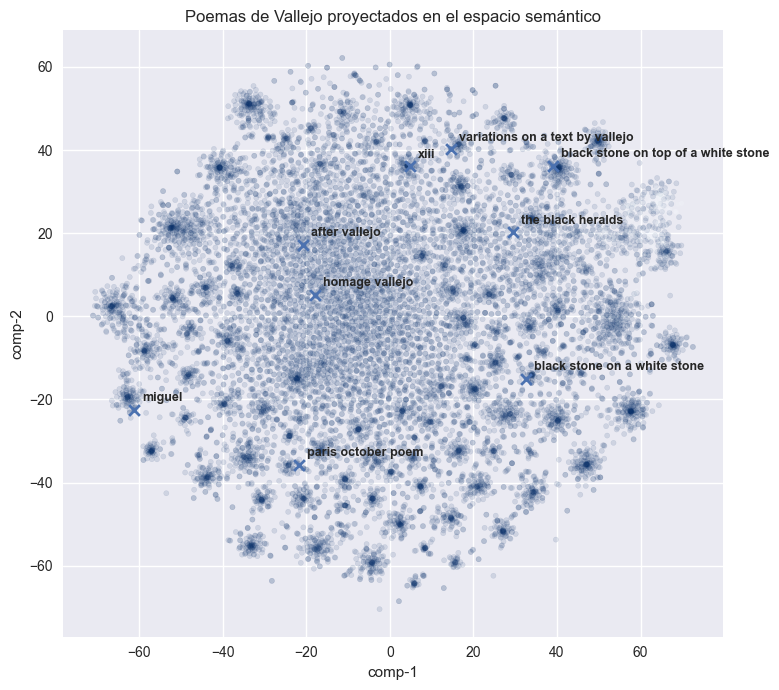

Figura guardada en: /VersoVector/figs/vallejo_projection.png


In [7]:
if not vallejo_view.empty and {"embedding_x", "embedding_y", "cluster_km"}.issubset(vallejo_view.columns):
    fig, ax = plt.subplots(figsize=(8, 7))

    ax.scatter(
        integrated["embedding_x"],
        integrated["embedding_y"],
        c=integrated["cluster_km"],
        s=14,
        alpha=0.12,
        cmap="Blues_r",
    )

    ax.scatter(
        vallejo_view["embedding_x"],
        vallejo_view["embedding_y"],
        s=60,
        marker="x",
        linewidths=2,
    )

    for _, row in vallejo_view.iterrows():
        ax.annotate(
            row["title"],
            xy=(row["embedding_x"], row["embedding_y"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9,
            weight="bold",
        )

    ax.set_title("Poemas de Vallejo proyectados en el espacio semántico")
    ax.set_xlabel("comp-1")
    ax.set_ylabel("comp-2")

    plt.tight_layout()

    out = fig_path("vallejo_projection.png")
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Figura guardada en: {display_path(out)}")
else:
    print("No hay filas de Vallejo o faltan coordenadas 2D.")

## 4. Top tags por cluster

Usa el artefacto `top_tags_by_cluster.csv` si existe.
Si no existe, lo reconstruye desde `integrated_results.csv`.

In [8]:
top_tags_path = artifact_path("integration", "top_tags_by_cluster.csv")

if top_tags_path.is_file():
    top_tags: PandasDF = load_csv(top_tags_path)
else:
    exploded = (
        integrated
        .explode("predicted_tags")
        .dropna(subset=["predicted_tags"])
    )

    top_tags = (
        exploded
        .groupby(["cluster_km", "predicted_tags"])
        .size()
        .reset_index(name="count")
        .sort_values(["cluster_km", "count"], ascending=[True, False])
        .groupby("cluster_km")
        .head(5)
        .reset_index(drop=True)
    )

display(top_tags)

,cluster_km,predicted_tags,count
0,0.0,living,6091
1,0.0,social commentaries,3385
2,0.0,nature,2767
3,0.0,relationships,1643
4,0.0,arts sciences,1148
5,1.0,love,121
6,1.0,living,67
7,1.0,nature,67
8,1.0,relationships,62
9,1.0,religion,58


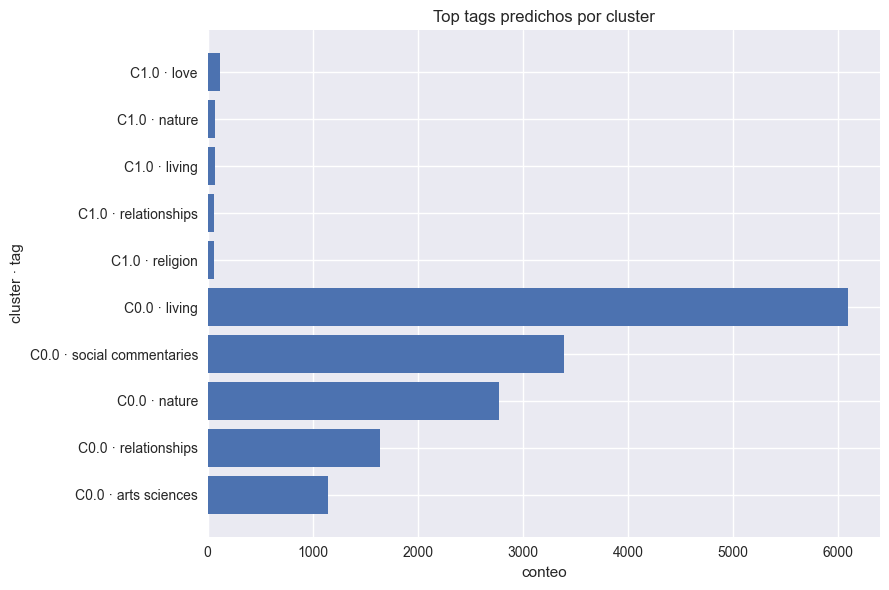

Figura guardada en: /VersoVector/figs/top_tags_by_cluster.png


In [9]:
if not top_tags.empty:
    plot_df = top_tags.copy()
    plot_df["cluster_tag"] = (
        "C"
        + plot_df["cluster_km"].astype(str)
        + " · "
        + plot_df["predicted_tags"].astype(str)
    )

    plot_df = plot_df.sort_values(
        ["cluster_km", "count"],
        ascending=[True, True],
    )

    fig_height = max(6, 0.28 * len(plot_df))

    fig, ax = plt.subplots(figsize=(9, fig_height))

    ax.barh(
        plot_df["cluster_tag"],
        plot_df["count"],
    )

    ax.set_title("Top tags predichos por cluster")
    ax.set_xlabel("conteo")
    ax.set_ylabel("cluster · tag")

    plt.tight_layout()

    out = fig_path("top_tags_by_cluster.png")
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Figura guardada en: {display_path(out)}")
else:
    print("No hay tags predichos para graficar.")

## 5. Matriz cluster vs fuente

In [10]:
cluster_source_path = artifact_path("integration", "cluster_source_matrix.csv")

if cluster_source_path.is_file():
    cluster_source_matrix: PandasDF = load_csv(cluster_source_path)
else:
    cluster_source_matrix = pd.crosstab(
        integrated["cluster_km"],
        integrated["source"],
        normalize="index",
    ).round(3).reset_index()

display(cluster_source_matrix.head())

,cluster_km,cesar_vallejo,poetry_foundation
0,0.0,0.0,1.0
1,1.0,0.0,1.0


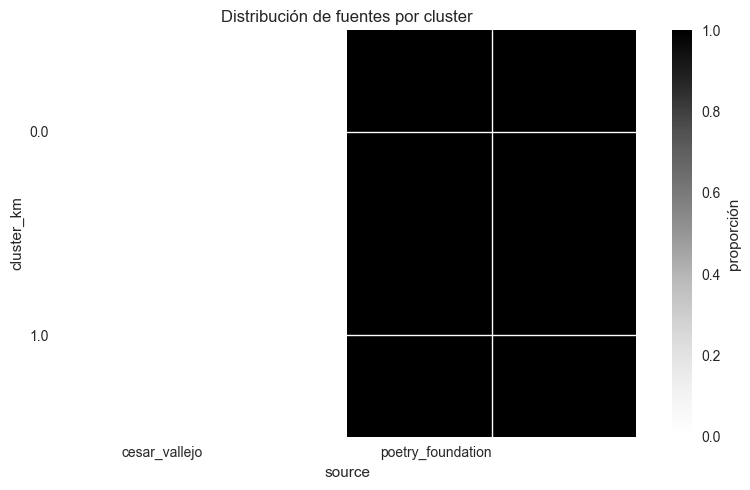

Figura guardada en: /VersoVector/figs/cluster_source_matrix.png


In [12]:
if "cluster_km" in cluster_source_matrix.columns and cluster_source_matrix.shape[1] > 1:
    matrix_df = cluster_source_matrix.set_index("cluster_km")

    fig, ax = plt.subplots(figsize=(8, 5))

    im = ax.imshow(matrix_df.values, aspect="auto")

    ax.set_title("Distribución de fuentes por cluster")
    ax.set_xlabel("source")
    ax.set_ylabel("cluster_km")

    ax.set_xticks(np.arange(matrix_df.shape[1]))
    ax.set_xticklabels(matrix_df.columns, rotation=0, ha="right")

    ax.set_yticks(np.arange(matrix_df.shape[0]))
    ax.set_yticklabels(matrix_df.index)

    plt.colorbar(im, ax=ax, label="proporción")

    plt.tight_layout()

    out = fig_path("cluster_source_matrix.png")
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Figura guardada en: {display_path(out)}")
else:
    print("No hay matriz cluster_source_matrix suficiente para graficar.")

## 6. Matriz cluster vs tópico LDA

In [13]:
cluster_topic_path = artifact_path("integration", "cluster_topic_matrix.csv")

if cluster_topic_path.is_file():
    cluster_topic_matrix: PandasDF = load_csv(cluster_topic_path)
else:
    cluster_topic_matrix = pd.crosstab(
        integrated["cluster_km"],
        integrated["lda_topic_id"],
        normalize="index",
    ).round(3).reset_index()

display(cluster_topic_matrix.head())

,cluster_km,0.0,1.0,2.0,3.0,4.0,5.0,6.0
0,0.0,0.036,0.176,0.097,0.058,0.263,0.243,0.127
1,1.0,0.005,0.011,0.164,0.803,0.003,0.005,0.008


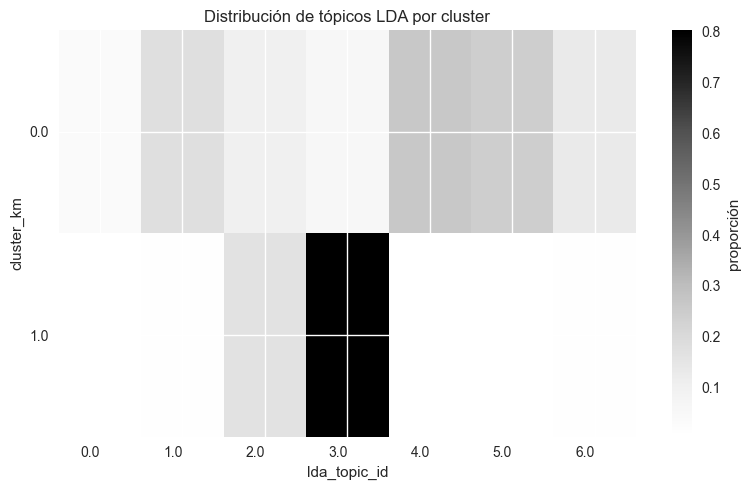

Figura guardada en: /VersoVector/figs/cluster_topic_matrix.png


In [15]:
if "cluster_km" in cluster_topic_matrix.columns and cluster_topic_matrix.shape[1] > 1:
    matrix_df = cluster_topic_matrix.set_index("cluster_km")

    fig, ax = plt.subplots(figsize=(8, 5))

    im = ax.imshow(matrix_df.values, aspect="auto")

    ax.set_title("Distribución de tópicos LDA por cluster")
    ax.set_xlabel("lda_topic_id")
    ax.set_ylabel("cluster_km")

    ax.set_xticks(np.arange(matrix_df.shape[1]))
    ax.set_xticklabels(matrix_df.columns, rotation=0, ha="right")

    ax.set_yticks(np.arange(matrix_df.shape[0]))
    ax.set_yticklabels(matrix_df.index)

    plt.colorbar(im, ax=ax, label="proporción")

    plt.tight_layout()

    out = fig_path("cluster_topic_matrix.png")
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Figura guardada en: {display_path(out)}")
else:
    print("No hay matriz cluster_topic_matrix suficiente para graficar.")

## 7. Resumen de figuras generadas

In [ ]:
generated_figures = [
    fig_path("poemas_2d_integracion.png"),
    fig_path("vallejo_projection.png"),
    fig_path("top_tags_by_cluster.png"),
    fig_path("cluster_source_matrix.png"),
    fig_path("cluster_topic_matrix.png"),
]

existing_figures = [
    display_path(path)
    for path in generated_figures
    if path.is_file()
]

existing_figures